In [9]:
# !git clone https://github.com/cybergalactic/PythonVehicleSimulator.git
# !cd /content/PythonVehicleSimulator && /usr/bin/python3 -m pip install -e .
# # reinitializing python configuration after installing the package
# import site
# site.main()

In [10]:
import os
import sys
import webbrowser
import matplotlib.pyplot as plt
import numpy as np
import math
from python_vehicle_simulator.vehicles import remus100,otter
from python_vehicle_simulator.lib import (
    printVehicleinfo, plotVehicleStates, plotControls,
    plot3D, attitudeEuler
)

In [11]:
def sawtooth(x):
    # return (x + pi) % (2 * pi) - pi  # or equivalently   2*arctan(tan(x/2))
    return 2*np.arctan(np.tan(x/2))

def make_boustrophedon_path(p1,yaw0,l,r,N,turn_direction):
    """
    Make a boustrophedon path for the vehicle to follow.
    p1: starting point
    dir: direction of the path at the starting point (radius)
    l: length of one transect
    r: distance between two transects
    N: number of transects
    turn_direction: direction of the first turn (1: left, -1: right)

    return: L_p the list of the waypoints
    """
    L_p = []
    pi = p1 # start of a transect
    yaw_i = yaw0 # direction of the transect
    turn_direction_i = turn_direction
    for i in range(N):
        pj = pi + l*np.array([np.cos(yaw_i), np.sin(yaw_i)]) # end of the transect
        L_p.append(pi)
        L_p.append(pj)
        pi = pj + r*np.array([np.cos(yaw_i+turn_direction_i*np.pi/2), np.sin(yaw_i+turn_direction_i*np.pi/2)])
        yaw_i = yaw_i + np.pi
        turn_direction_i = -turn_direction_i

    return L_p

def draw_boustrophedon_path(ax,L_p,linewidth=5,reverse=False):
    """
    Draw the boustrophedon path
    L_p: list of waypoints
    """
    N = int(len(L_p)/2) # number of transects
    for i in range(N):
        #draw the transect line
        pi = L_p[2*i]
        pj = L_p[2*i+1]

        ax.plot([pi[0],pj[0]],[pi[1],pj[1]],'y',linewidth=linewidth)
        if i > 0:
            #draw the turn circular arc
            pk = L_p[2*i-1]
            center = 0.5 * (pi + pk)
            r = np.linalg.norm(center - pi)

            # get the angle of the circular arc for pk and pi
            pk_angle = np.arctan2(pk[1]-center[1],pk[0]-center[0])
            turndir = -np.sign(np.cross(pk-pi,pj-pi))

            theta = np.linspace(pk_angle, pk_angle+turndir*np.pi, 100)

            x = center[0] + r*np.cos(theta)
            y = center[1] + r*np.sin(theta)
            ax.plot(x,y,'y',linewidth=linewidth)
    # draw a disk at the end of the path with a radius of 1.5*linewidth
    ax.plot(L_p[-1][0],L_p[-1][1],'yo',markersize=1.5*linewidth)

def boustrophedon_closest_point_and_yaw(pr,u,L_p,step):
    """
        Given the position of the robot pr and the step in the boustrophedon guidance,
        compute the closest point pc of the path and the associated yaw_c, and the distance to the path e.
        pr: position of the robot
        vr: speed vector of the robot [x_dot,y_dot]
        L_p: list of waypoints
        step: step in the boustrophedon guidance in [1,2N-1]

        return :
        pc: closest point on the path
        e: distance to the path
        yaw_c: direction of the path at pc
        u : surge_speed on the path
    """
    # verify that the step is in the range of the path
    N = int(len(L_p)/2) # number of transects
    if step < 1 or step > 2*N-1:
        print("Error: step out of range")
        return None

    # check if the step is a turn (even) or a transect (odd)
    if step % 2 == 0:
        # the step is a turn
        i = step -1
        # pj -> pk -> pi
        pk = L_p[i] # start of the turn
        pi = L_p[i+1] # end of the turn
        pj = L_p[i-1] # beginning of the previous transect

        center = 0.5 * (pi + pk)
        r = np.linalg.norm(center - pi)

        vect = pr - center
        pc = center + r * vect / np.linalg.norm(vect)
        yaw_c = np.arctan2(pc[1]-center[1],pc[0]-center[0]) + np.sign(np.cross(pk-pi,pr-pj))*np.pi/2
        vi = np.array([np.cos(yaw_c),np.sin(yaw_c)])
        # yaw_c_dot = np.dot(vr,vi)/r * np.sign(np.cross(pk-pi,pr-pi))
        # yaw_c_dot = 0.001*np.cross(vect,vr)/np.linalg.norm(vect)
        yaw_c_dot = u/r * np.sign(np.cross(pk-pi,pr-pi))
    else:
        # the step is a transect pi -> pj
        pi = L_p[step-1]
        pj = L_p[step]

        # yaw_c is the direction of the transect
        yaw_c = np.arctan2(pj[1]-pi[1],pj[0]-pi[0])
        yaw_c_dot = 0
        vi = np.array([np.cos(yaw_c),np.sin(yaw_c)])
        pc =  pi + np.dot(pr-pi,pj-pi)/(np.linalg.norm(pj-pi)**2)*(pj-pi)

    e = np.linalg.norm(pr-pc)
    # make e negative if the robot is on the right part of the path
    if np.cross(pr-pc,vi) > 0:
        e = -e
    return pc,e,yaw_c,yaw_c_dot

def update_step(L_p,step,pr,vr):
    """
    Update the step of the boustrophedon guidance
    L_p: list of waypoints
    step: current step in [1,2N-1]
    pr: position of the robot [px,py]
    vr: speed vector of the robot [px_dot,py_dot]
    """
    # verify that the step is in the range of the path
    N = int(len(L_p)/2) # number of transects
    if step < 1 or step > 2*N-1:
        print("Error: step out of range")
        return None
    # check if the step is a turn (even) or a transect (odd)
    if step % 2 == 0:
        # this is a turn
        pi = L_p[step] # end of the turn
        pj = L_p[step+1] # end of next transect
        yaw_i = np.arctan2(pj[1]-pi[1],pj[0]-pi[0]) # direction of the next transect
    else:
        # this is a transect
        pi = L_p[step] # end of the transect
        pj = L_p[step-1] # start of the transect
        yaw_i = np.arctan2(pi[1]-pj[1],pi[0]-pj[0]) # direction of the transect
    vi = np.array([np.cos(yaw_i),np.sin(yaw_i)]) # direction vector of the transect

    # two condition must be matched to update the step
    # 1 - the robot must have past the half plan orthogonal to the path at pi
    # 2 - vr and vi must have the same direction
    if np.dot(pr-pi,vi) > 0 and np.dot(vr,vi) > 0:
        step = step + 1
        # print("step updated at position ",pr)
    return step



We define the controller function again as in the previous exercice. Carefull, the controllers are now called my_controller for both systems and the control reference is in the input of the function. Moreover, This time, the heading rate is non zero

In [ ]:
class myOtter(otter):
    def __init__(
        self,
        controlSystem,
        u_d,
        V_current,
        beta_current
        ):
        """
        Inputs:
            controlSystem: type of controller (string)
            u_d: desired speed (m/s)
            V_c: current speed (m/s)
            beta_c: current direction (deg)
            tau_X: surge force, pilot input (N)
        """
        mycontrolSystem = str(controlSystem)
        super().__init__(controlSystem,0,V_current,beta_current,0)
        # self.D2R = np.pi/180
        if mycontrolSystem == "my_controller":
                self.u_d = u_d # to remember the value, constant by default
                self.a_d = 0 # desired acceleration, 0 by default
                self.r_d = 0 # desired angular velocity, 0 by default
                self.e_u_int = 0 # to rember the integral error of the speed
                self.e_psi_int = 0 # to rembmer the integral error of the headind
                self.controlMode = mycontrolSystem

    def my_controller(self, eta, nu,ref, sampleTime):
        """
        u = speedheadingAutopilot(eta,nu,ref,sampleTime) is a controller
        for automatic speed and heading control.

        Here you can implement a PI control for heading and a PID control for the heading

        # ref = np.array([u_d, yaw_d, r_d, z_d], float), z_d = 0

        """
        psi = eta[5]  # yaw angle
        r = nu[5]  # yaw rate
        r_d = ref[2] # desired yaw rate
        psi_d = ref[1] # desired heading
        e_psi = sawtooth(psi_d - psi)  # yaw angle tracking error in rad
        e_r = r_d - r  # yaw rate tracking error

        u = nu[0] # the surge
        u_d= ref[0] # the desired surge
        e_u = u_d - u


        # integrate the errors
        self.e_u_int += e_u * sampleTime
        self.e_psi_int += e_psi * sampleTime

        # PID gains
        Kpu, Kiu = 100.0, 10.0 # gains for speed
        Kpy, Kiy, Kdy = 10.0, 0.1, 5.0 # gain for heading


        # PID feedback controller with 3rd-order reference model
        """ 
        Formula: -Kpu * e_u - Kiu * self.e_u_int + Kdu * (e_u - self.e_u_prev) / sampleTime <- the second term is the 
        integral term, the third term is the derivative term but we don't have acceleration measurement so we 
        cannot implement it
        """
        tau_X = (Kpu * e_u + Kiu * self.e_u_int) # forward trust
        tau_N = (Kpy * e_psi + Kiy * self.e_psi_int + Kdy * e_r) # turning momentum

        # control allocation, use self.Binv
        """B = control effectiveness matrix, u_alloc = control allocation, tau = desired forces and moments"""

        tau = np.array([tau_X, tau_N])  # tau = B * u_alloc
        u_alloc = self.Binv @ tau # u_alloc = inv(B) * tau

        # u_alloc = abs(n) * n --> n = sign(u_alloc) * sqrt(u_alloc)
        n_left = np.sign(u_alloc[0]) * np.sqrt(np.abs(u_alloc[0]))
        n_right = np.sign(u_alloc[1]) * np.sqrt(np.abs(u_alloc[1]))

        u_control = np.array([n_left, n_right], float) # left and right RPM

        return u_control, e_u, e_psi, 0


class myRemus1000(remus100):
    def __init__(self,
                controlSystem,
                z_d,
                u_d,
                V_current,
                beta_current):
        """
        Inputs:
            controlSystem: type of controller (string)
            z_d: desired depth (m)
            u_d: desired speed (m/s)
            V_c: current speed (m/s)
            beta_c: current direction (deg)
        """
        mycontrolSystem = str(controlSystem)
        super().__init__(controlSystem,0,0,0,V_current,beta_current)
        if mycontrolSystem == "my_controller":
            self.u_d = u_d # desired speed, constant but can be modified in the simulate function
            self.r_d = 0 # desired angular velocity, 0 by default
            self.z_d = z_d # desired depth
            self.e_u_int = 0 # integral terms
            self.e_psi_int = 0
            self.e_z_int = 0
            self.controlMode = mycontrolSystem

    def my_controller(self,eta,nu,ref, sampleTime):
        """
        [delta_r, delta_s, n] = speedDepthHeadingPiController(eta,nu,ref,sampleTime)
        simultaneously control the speed, depth and heading of the AUV.
        PID controller for heading and depth
        PI for speed

        Returns:

            u_control = [ delta_r   rudder angle (rad)
                         delta_s    stern plane angle (rad)
                         n          propeller revolution (rpm) ]
        # ref = np.array([u_d, yaw_d, r_d, z_d], float),

        """

        # get the reference point
        u_d = ref[0] # desired speed
        psi_d = ref[1] # desired heading
        z_d = ref[3] # desired depth
        r_d = ref[2] # desired heading rate

        # get the state
        u = nu[0] # the speed
        psi = eta[5] # the heading
        z = eta[2] # depth

        pitch = eta[4] # pitch
        pitch_rate = nu[4] # pitch rate
        r = nu[5] # heading rate

        # errors
        e_u = u_d - u
        e_psi = sawtooth(psi_d - psi)
        e_r = r_d - r
        e_pitch_rate = 0-pitch_rate # reference is always 0
        e_pitch = 0-pitch # reference is always 0
        e_z =  z_d - z

        # integrate the errors
        self.e_u_int += e_u * sampleTime
        self.e_psi_int += e_psi * sampleTime
        self.e_z_int += e_z * sampleTime

        # PI controllers
        Kpn, Kin = 150., 100. # gains for surge velocity
        Kpy, Kiy = 100., 0.0 # gains for yaw angle
        G1, G2, G3 = 1., 10., 10. # gains for depth control, G1 for depth error, G2 for pitch, G3 for pitch rate

        tau_yaw = - Kpy * e_psi - Kiy * self.e_psi_int
        delta_r = - tau_yaw / self.K_nomoto
        delta_s =  G1* e_z + G2 * pitch + G3 * pitch_rate
        n = Kpn * e_u + Kin * self.e_u_int

        u_control = np.array([delta_r, delta_s, n], float)

        return u_control, e_u, e_psi, e_z


The guidance must be implemented in the following block in the simulation loop before the controllers

In [13]:
def my_simulate(N, sampleTime, vehicle, L_p=None):
    DOF = 6  # degrees of freedom
    t = 0  # initial simulation time

    # Initial state vectors
    eta = np.array([0, 0, 0, 0, 0, 0], float)  # position/attitude, user editable
    nu = vehicle.nu  # velocity, defined by vehicle class
    u_actual = vehicle.u_actual  # actual inputs, defined by vehicle class

    # Initialization of table used to store the simulation data
    simData = np.empty([0, 2 * DOF + 2 * vehicle.dimU], float)

    step = 1
    myData = np.empty([0, 5], float)

    # Simulator for-loop
    yaw_d = eta[5]
    for i in range(0, N + 1):

        t = i * sampleTime  # simulation time

        # Vehicle specific control systems
        pr = np.array([eta[0], eta[1]], float)
        vr_robot = np.array([nu[0], nu[1]], float)

        # convert vr_robot to the world frame
        yaw = eta[5]
        R = np.array([[np.cos(yaw), -np.sin(yaw)], [np.sin(yaw), np.cos(yaw)]])
        vr = np.dot(R, vr_robot)

        # print("\ndebug1",pr,vr,vr_robot,yaw)
        if step > len(L_p) - 1:  # break
            if type(vehicle) == myRemus1000:
              u_control = np.array([0, 0, 0], float)
            else:
              u_control = np.array([0, 0], float)
            my_signal = np.array([step, 0, 0, 0, 0])
        else:
            if type(vehicle) == myRemus1000:
              u_d = vehicle.u_d # desired speed
              z_d = vehicle.z_d # desired depth
            else: # otter
              u_d = vehicle.u_d # desired depth
              z_d = 0

            #---------------------------------------------------------------------------------
            # TODO implement the guidance. you can use boustrophedon_closest_point_and_yaw
            #---------------------------------------------------------------------------------
            _, e, yaw_c, yaw_c_dot = boustrophedon_closest_point_and_yaw(pr, u_d, L_p, step)
            Delta = 5.
            yaw_old_d = yaw_d
            yaw_d = yaw_c + np.arctan(-e / Delta)
            r_d = (yaw_d - yaw_old_d)/sampleTime

            # apply reference points
            ref = np.array([u_d, yaw_d, r_d, z_d], float)
            u_control, e_u, e_yaw, e_z = vehicle.my_controller(eta, nu, ref, sampleTime)
            my_signal = np.array([step, e, e_u, e_yaw, e_z])

            step = update_step(L_p, step, pr, vr)

        # Store simulation data in simData
        signals = np.append(np.append(np.append(eta, nu), u_control), u_actual)
        simData = np.vstack([simData, signals])
        if my_signal is not None:
            myData = np.vstack([myData, my_signal])

        # Propagate vehicle and attitude dynamics
        nu, u_actual = vehicle.dynamics(eta, nu, u_actual, u_control, sampleTime)
        eta = attitudeEuler(eta, nu, sampleTime)

    # Store simulation time vector
    simTime = np.arange(start=0, stop=t + sampleTime, step=sampleTime)[:, None]
    return (simTime, simData, myData)


In [14]:
# Simulation parameters:
sim_time = 1000.0                     # simulation time [seconds]
sampleTime = 0.06                   # sample time [seconds]
N = int(sim_time/sampleTime)        # number of samples
# N = 10000                           # number of samples

# 3D plot and animation parameters where browser = {firefox,chrome,safari,etc.}
numDataPoints = 50                  # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF

---------------------------------------------------------------------------------------
Otter USV (see 'otter.py' for more details)
Length: 2.0 m
Step inputs for n1 and n2
Sampling frequency: 17 Hz
Simulation time: 1000 seconds
---------------------------------------------------------------------------------------


C:\Users\natal\AppData\Local\Temp\ipykernel_15900\4076725036.py:114: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(pr-pc,vi) > 0:
C:\Users\natal\AppData\Local\Temp\ipykernel_15900\4076725036.py:96: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  yaw_c = np.arctan2(pc[1]-center[1],pc[0]-center[0]) + np.sign(np.cross(pk-pi,pr-pj))*np.pi/2
C:\Users\natal\AppData\Local\Temp\ipykernel_15900\4076725036.py:100: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  yaw_c_dot = u/r * np.sign(np.cross(pk-pi,pr-pi))
C:\Users\natal\AppData\Local\Temp\ipykernel_15900\4076725036.py:51: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 

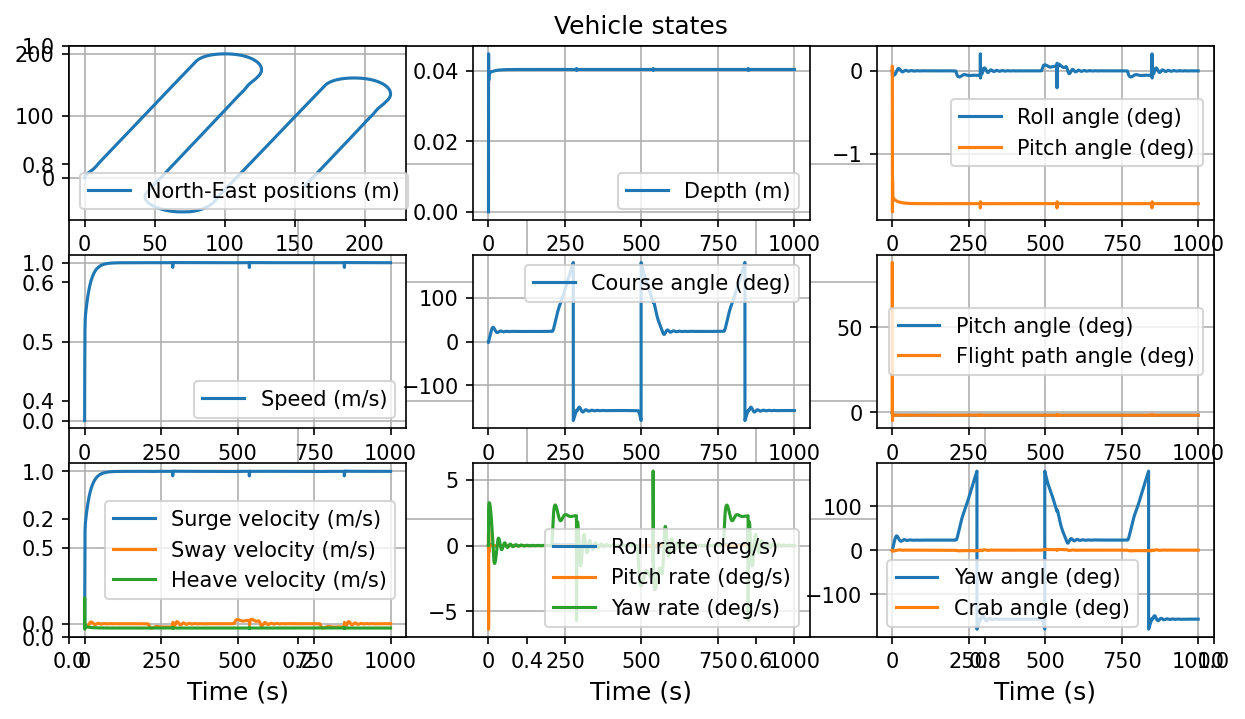

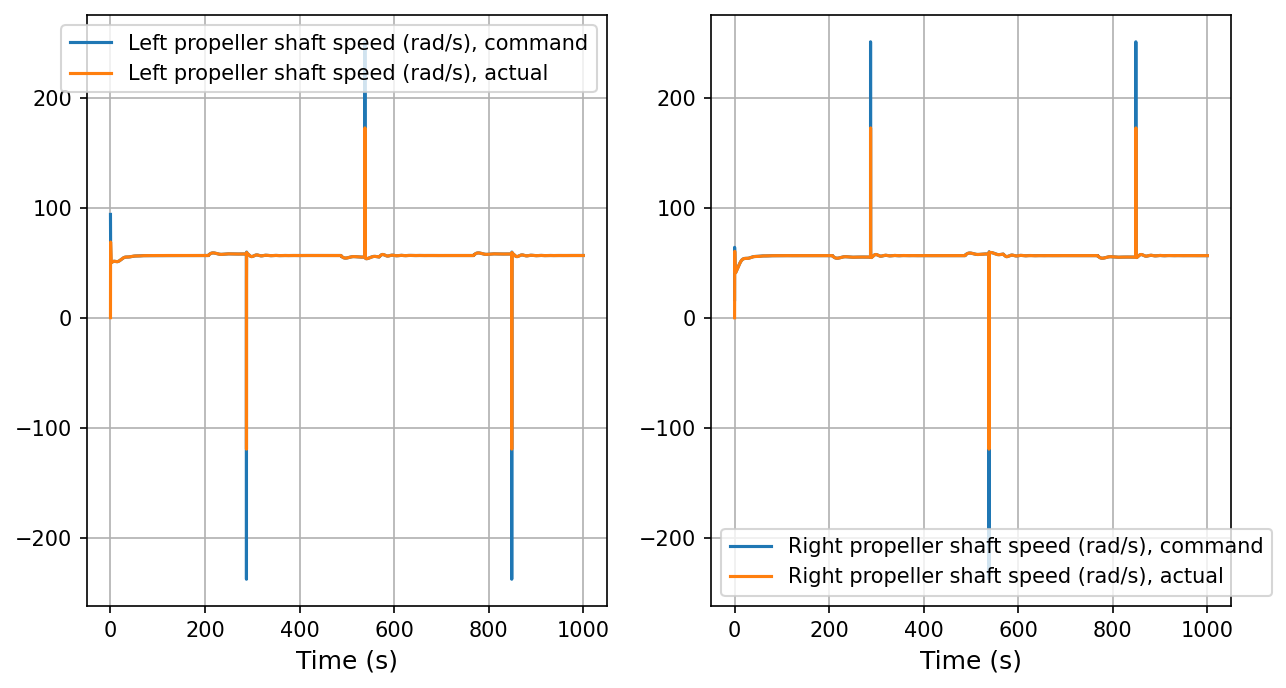

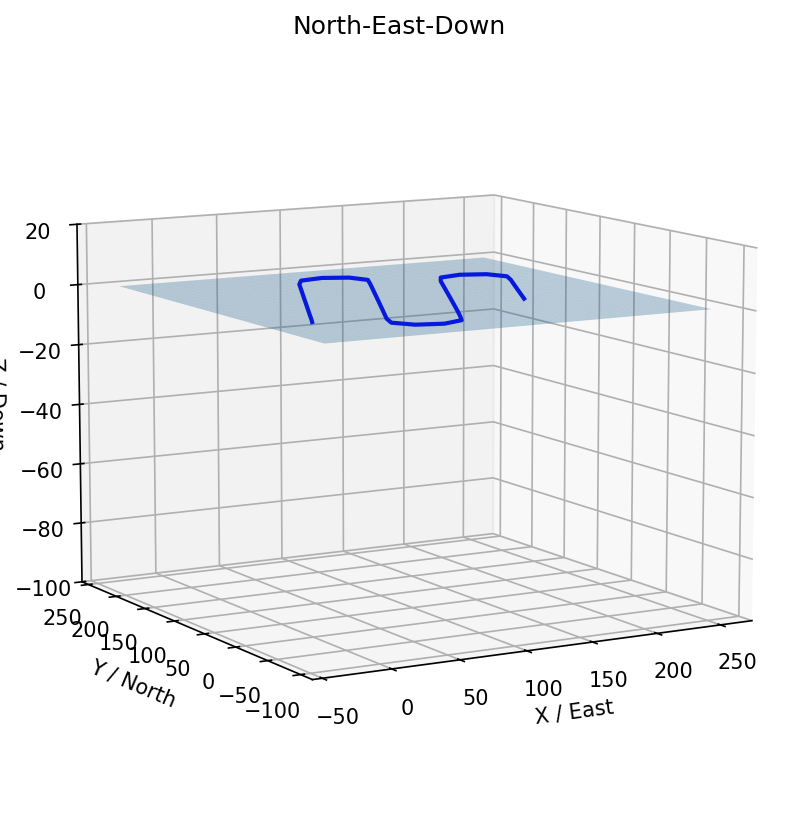

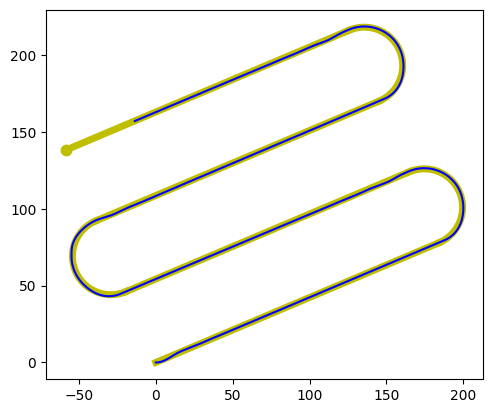

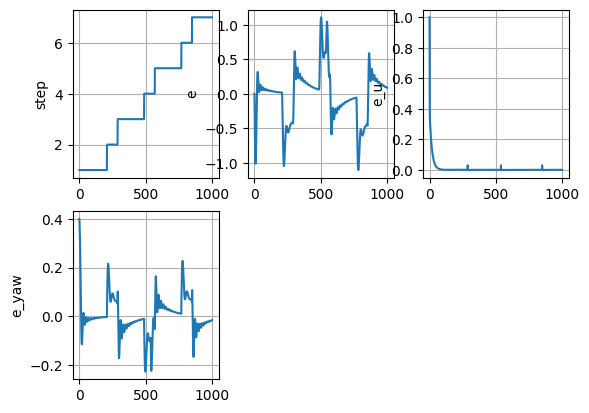

In [15]:
vehicle = myOtter("my_controller",u_d=1.,V_current=0.,beta_current=0.)
printVehicleinfo(vehicle, sampleTime, N)

# path definition
p1_ = np.array([0, 0])
yaw0_ = 0.4
l_ = 200
r_ = 50
N_ = 4
turn_direction_ = 1
L_p = make_boustrophedon_path(p1_, yaw0_, l_, r_, N_, turn_direction_)

# Main simulation loop
[simTime, simData,myData] = my_simulate(N, sampleTime, vehicle,L_p)

plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)
plot3D(simData, numDataPoints, FPS, filename, 3)

fig = plt.figure()
ax = fig.add_subplot(111, aspect='equal')
draw_boustrophedon_path(ax,L_p)
x = simData[:, 0]
y = simData[:, 1]
ax.plot(x,y,'b')

t =  simTime
steps = myData[:,0]
e =  myData[:,1]
e_u = myData[:,2]
e_yaw = myData[:,3]
e_d = myData[:,4]

fig = plt.figure()
ax = fig.add_subplot(231)
ax.plot(t,steps)
ax.set_ylabel('step')
ax.grid()

ax = fig.add_subplot(232)
ax.plot(t,e)
ax.set_ylabel('e')
ax.grid()

ax = fig.add_subplot(233)
ax.plot(t,e_u)
ax.set_ylabel('e_u')
ax.grid()

ax = fig.add_subplot(234)
ax.plot(t,e_yaw)
ax.set_ylabel('e_yaw')
ax.grid()

C:\Users\natal\AppData\Local\Temp\ipykernel_15900\4076725036.py:114: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(pr-pc,vi) > 0:
C:\Users\natal\AppData\Local\Temp\ipykernel_15900\4076725036.py:96: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  yaw_c = np.arctan2(pc[1]-center[1],pc[0]-center[0]) + np.sign(np.cross(pk-pi,pr-pj))*np.pi/2
C:\Users\natal\AppData\Local\Temp\ipykernel_15900\4076725036.py:100: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  yaw_c_dot = u/r * np.sign(np.cross(pk-pi,pr-pi))
C:\Users\natal\AppData\Local\Temp\ipykernel_15900\4076725036.py:51: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 

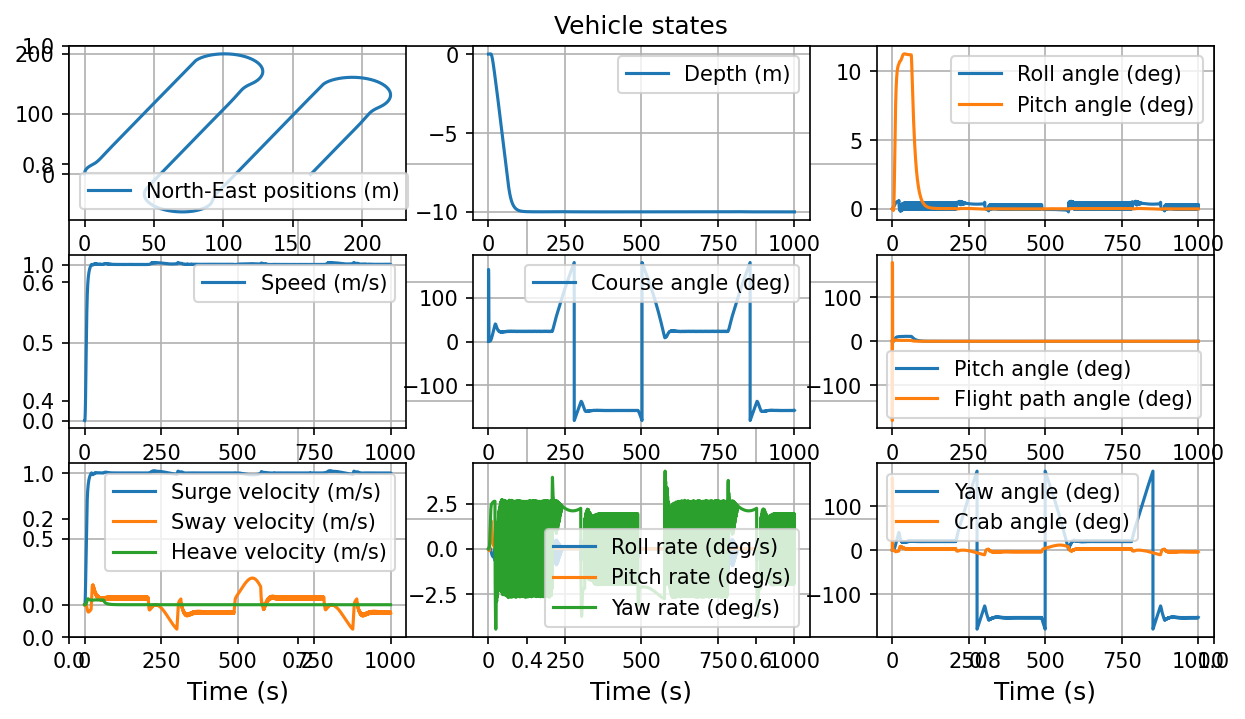

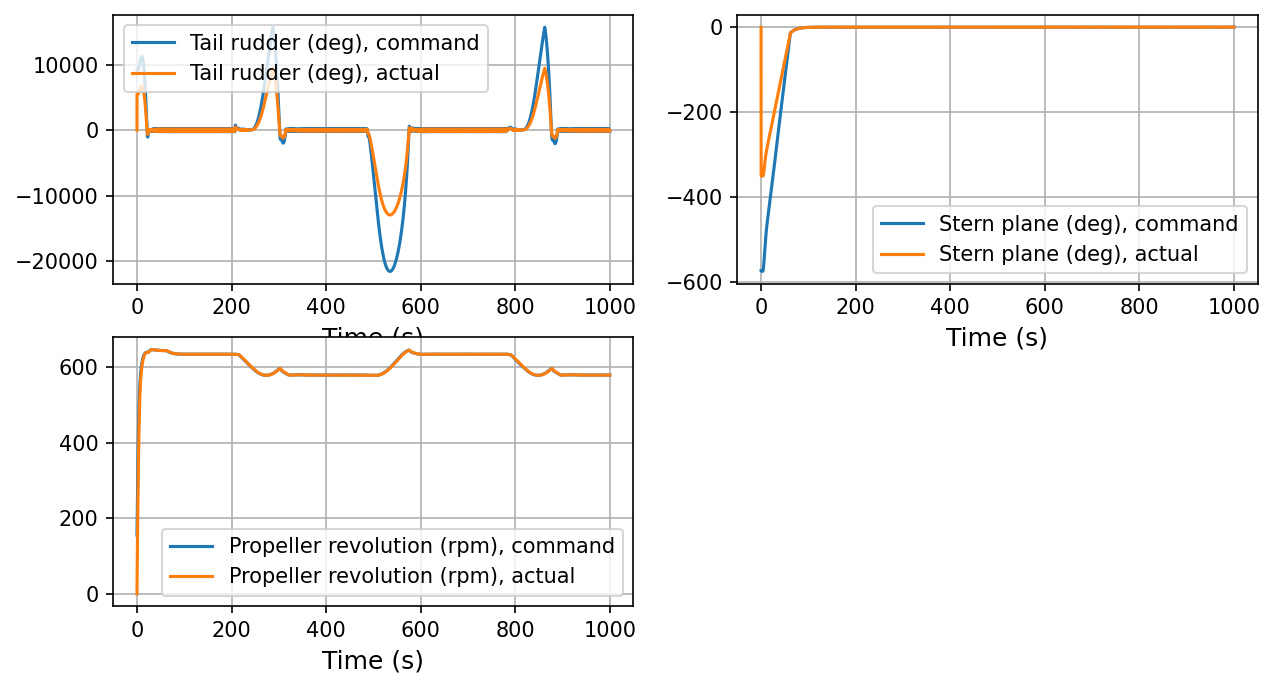

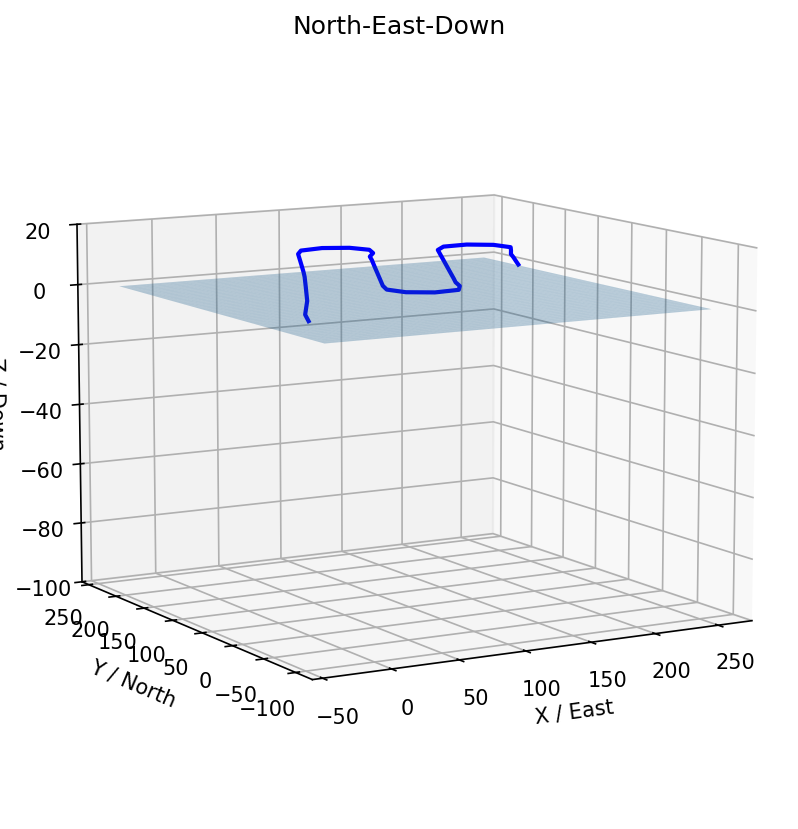

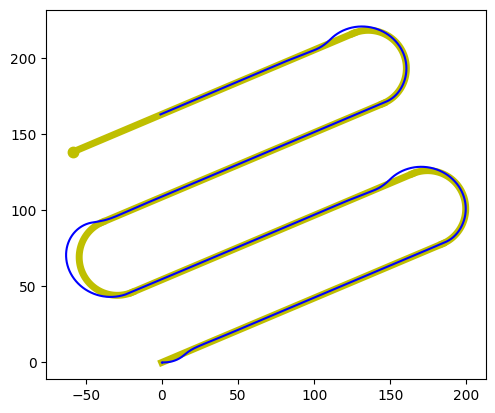

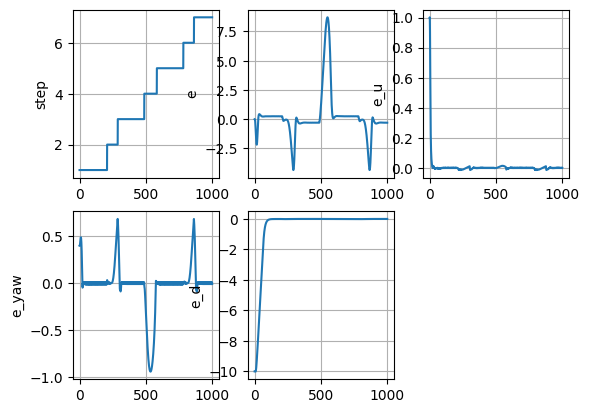

In [16]:
vehicle = myRemus1000(controlSystem='my_controller',z_d=-10, u_d = 1., V_current=0.1, beta_current=170)

p1_ = np.array([0, 0])
yaw0_ = 0.4
l_ = 200
r_ = 50
N_ = 4
turn_direction_ = 1
L_p = make_boustrophedon_path(p1_, yaw0_, l_, r_, N_, turn_direction_)

[simTime, simData,myData] = my_simulate(N, sampleTime, vehicle,L_p)

plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)
plot3D(simData, numDataPoints, FPS, filename, 3)

fig = plt.figure()
ax = fig.add_subplot(111, aspect='equal')
draw_boustrophedon_path(ax,L_p)
x = simData[:, 0]
y = simData[:, 1]
ax.plot(x,y,'b')

t =  simTime
steps = myData[:,0]
e =  myData[:,1]
e_u = myData[:,2]
e_yaw = myData[:,3]
e_d = myData[:,4]

fig = plt.figure()
ax = fig.add_subplot(231)
ax.plot(t,steps)
ax.set_ylabel('step')
ax.grid()

ax = fig.add_subplot(232)
ax.plot(t,e)
ax.set_ylabel('e')
ax.grid()

ax = fig.add_subplot(233)
ax.plot(t,e_u)
ax.set_ylabel('e_u')
ax.grid()

ax = fig.add_subplot(234)
ax.plot(t,e_yaw)
ax.set_ylabel('e_yaw')
ax.grid()

ax = fig.add_subplot(235)
ax.plot(t,e_d)
ax.set_ylabel('e_d')
ax.grid()